# Outlier removal — explainer
### Showing the full source calibration, and exactly which filters we removed

This notebook makes the **cleaning step transparent** for the presentation:
1. **All the source samples** — the full IMPROVE EC calibration set (n=906) that the tool builds
   the calibration from, plotted measured-vs-predicted.
2. **Which ones are odd** — the residual diagnostics that flag the outliers.
3. **Before → after** — the same plot with the removed filters called out, and the cleaned result.
4. **The removed list** — a table of every filter we dropped, with site / date / loading / why.

*Calibration: `sklearn PLS(scale=False)` == the tool's kernelpls; component count fixed at **K=20**
(the stable mid-valley choice from the optimization notebook); cleaning = iterative 3σ residual
trimming (Mona's "remove the big offsets, rerun" made explicit).*

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":140,"font.size":11,"axes.grid":True,"grid.alpha":0.25})

def find_root(s=None):
    p=Path(s or Path.cwd()).resolve()
    for c in [p,*p.parents]:
        if (c/"research").exists() and (c/"AGENTS.md").exists(): return c
    return Path.cwd()
HERE=find_root()/"research/spartan_ec_2026_06_16"; DATA=HERE/"data"; FIG=HERE/"figures"; FIG.mkdir(exist_ok=True); (HERE/"tables").mkdir(exist_ok=True)

X=pd.read_csv(DATA/"rds_EC_X.csv").drop(columns=["id"]).to_numpy(float)
y=pd.read_csv(DATA/"rds_EC_Ymeasured.csv")["Y_measured"].to_numpy(float)
wv=pd.read_csv(DATA/"rds_EC_coef_k18.csv")["wavenumber"].to_numpy(float)
meta=pd.read_csv(DATA/"rds_EC_metadata.csv")
info=pd.DataFrame({"Site":meta.Site,"date":pd.to_datetime(meta.SampleDate).dt.strftime("%Y-%m-%d"),
                   "FilterId":meta.MatchedFilterId,"AnalysisId":meta.FtirAnalysisId})
K=20
def fitpred(mask):
    m=PLSRegression(n_components=K,scale=False).fit(X[mask],y[mask]); return m.predict(X[mask]).ravel()
def stats(yt,pt):
    r=yt-pt; return dict(n=int(len(yt)),r2=1-np.sum(r**2)/np.sum((yt-yt.mean())**2),
        rmse=float(np.sqrt(np.mean(r**2))),errpct=100*np.mean(np.abs(r))/np.mean(yt))
print("full source calibration set: n =",len(y),"| measured EC median %.1f, max %.1f µg"%(np.median(y),y.max()))

full source calibration set: n = 906 | measured EC median 10.7, max 393.3 µg


## 1. All the source samples — the full calibration
Every matched IMPROVE filter (n=906), measured vs predicted at K=20. This is what the tool fits the
calibration on **before any cleaning**. A few points sit far off the 1:1 line — those are the ones
to deal with.

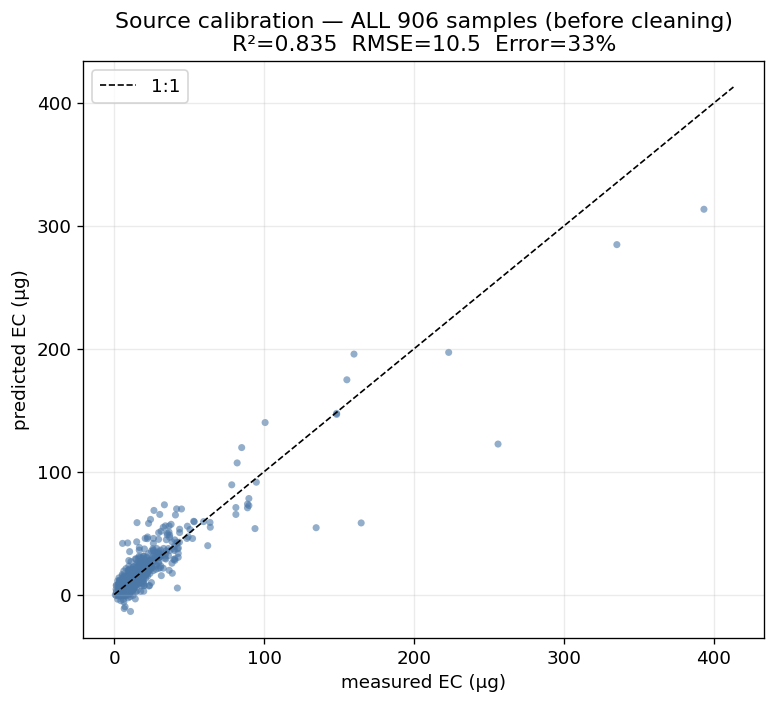

In [2]:
pred_full=fitpred(np.ones(len(y),bool)); s_full=stats(y,pred_full)
fig,ax=plt.subplots(figsize=(6.6,6))
ax.scatter(y,pred_full,s=18,c="#4c78a8",alpha=.6,edgecolor="none")
lim=max(y.max(),pred_full.max())*1.05; ax.plot([0,lim],[0,lim],"k--",lw=1,label="1:1")
ax.set(xlabel="measured EC (µg)",ylabel="predicted EC (µg)",
       title=f"Source calibration — ALL {s_full['n']} samples (before cleaning)\nR²={s_full['r2']:.3f}  RMSE={s_full['rmse']:.1f}  Error={s_full['errpct']:.0f}%")
ax.legend(); plt.tight_layout(); plt.savefig(FIG/"fig08_1_all_samples.png",bbox_inches="tight"); plt.show()

## 2. Which ones are odd — residual diagnostics
We flag outliers iteratively: fit, drop any filter whose \|residual\| exceeds 3× the residual spread,
re-fit, repeat until none exceed. (This mirrors Mona's manual "remove the big offsets, rerun.")

removal rounds (round, n_before, 3σ threshold µg, dropped):
   (1, 906, 31.6, 18)
   (2, 888, 13.6, 14)
   (3, 874, 9.9, 12)
   (4, 862, 8.7, 8)
   (5, 854, 8.1, 2)
   (6, 852, 7.9, 4)
   (7, 848, 7.9, 2)
   (8, 846, 7.9, 1)
   (9, 845, 7.8, 0)
TOTAL removed: 61 of 906 (6.7%)


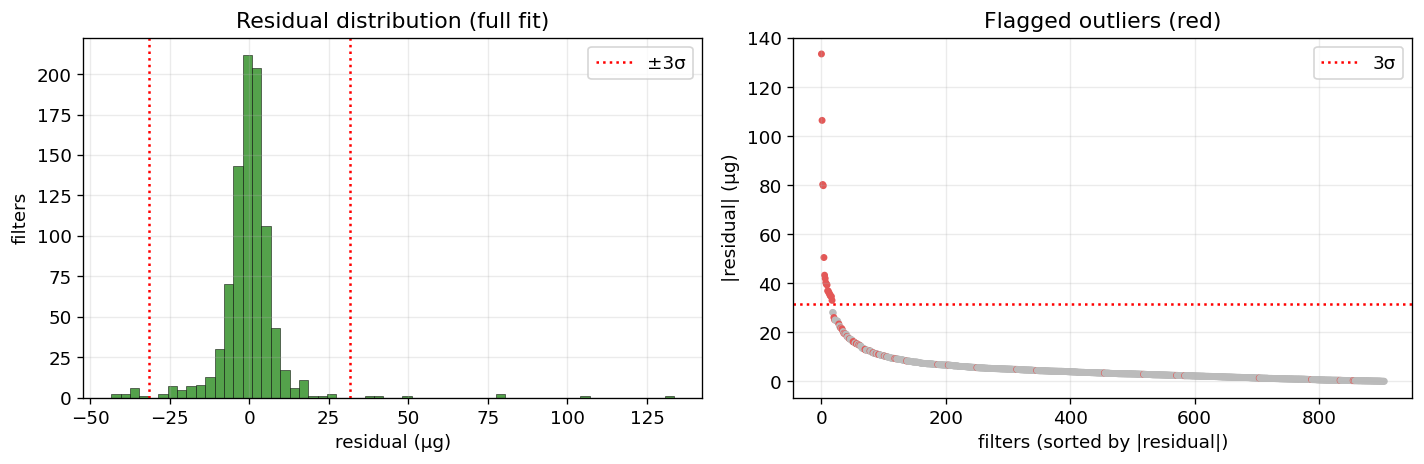

In [3]:
keep=np.ones(len(y),bool); removed_round=np.zeros(len(y),int); rnd=0; rounds=[]
while True:
    rnd+=1; pr=fitpred(keep); r=y[keep]-pr; thr=3*r.std()
    drop_local=np.abs(r)>thr; nd=int(drop_local.sum())
    rounds.append((rnd,int(keep.sum()),round(float(thr),1),nd))
    if nd==0 or rnd>8: break
    gi=np.where(keep)[0][drop_local]; removed_round[gi]=rnd; keep[gi]=False
removed=~keep
print("removal rounds (round, n_before, 3σ threshold µg, dropped):")
for r_ in rounds: print("  ",r_)
print("TOTAL removed: %d of %d (%.1f%%)"%(removed.sum(),len(y),100*removed.mean()))

# residual diagnostics on the full fit
resid_full=y-pred_full
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].hist(resid_full,bins=60,color="#54a24b",edgecolor="k",lw=.3)
for s in (3,):ax[0].axvline(s*resid_full.std(),color="r",ls=":");ax[0].axvline(-s*resid_full.std(),color="r",ls=":",label="±3σ")
ax[0].set(xlabel="residual (µg)",ylabel="filters",title="Residual distribution (full fit)"); ax[0].legend()
order=np.argsort(np.abs(resid_full))[::-1]
ax[1].scatter(range(len(resid_full)),np.abs(resid_full)[order],s=10,c=np.where(removed[order],"#e45756","#bbbbbb"))
ax[1].axhline(3*resid_full.std(),color="r",ls=":",label="3σ")
ax[1].set(xlabel="filters (sorted by |residual|)",ylabel="|residual| (µg)",title="Flagged outliers (red)"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG/"fig08_2_diagnostics.png",bbox_inches="tight"); plt.show()

## 3. Before → after — the removed filters called out
Left: all samples, with the **removed ones circled in red**. Right: the cleaned calibration.

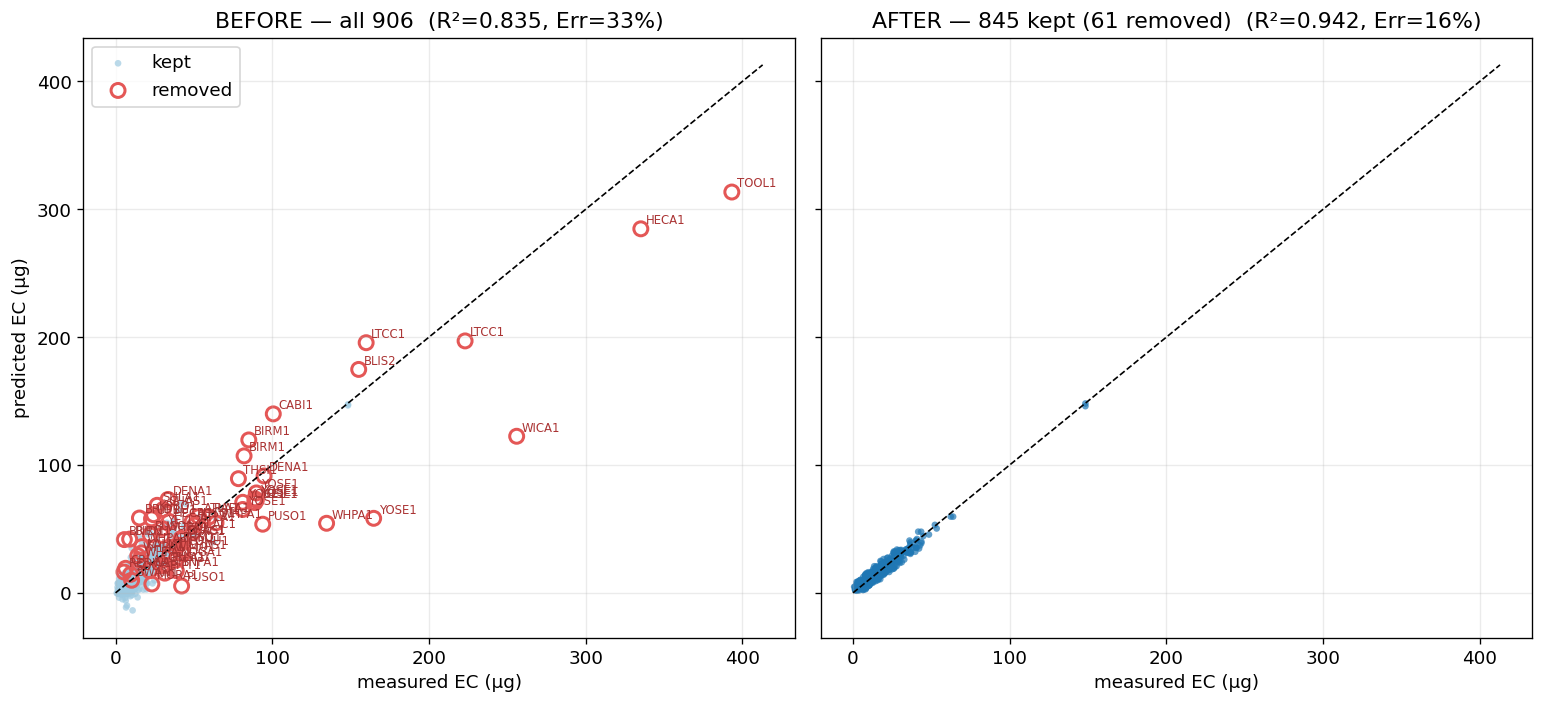

BEFORE: n=906 R²=0.835 RMSE=10.5 Err=33%
AFTER : n=845 R²=0.942 RMSE=2.6 Err=16%


In [4]:
pred_clean=fitpred(keep); s_clean=stats(y[keep],pred_clean)
fig,ax=plt.subplots(1,2,figsize=(13,6),sharex=True,sharey=True)
ax[0].scatter(y[~removed],pred_full[~removed],s=16,c="#9ecae1",alpha=.7,edgecolor="none",label="kept")
ax[0].scatter(y[removed],pred_full[removed],s=70,facecolors="none",edgecolors="#e45756",linewidths=1.8,label="removed")
for i in np.where(removed)[0]: ax[0].annotate(info.Site[i],(y[i],pred_full[i]),fontsize=7,color="#a33",xytext=(3,3),textcoords="offset points")
lim=max(y.max(),pred_full.max())*1.05
for a in ax: a.plot([0,lim],[0,lim],"k--",lw=1)
ax[0].set(xlabel="measured EC (µg)",ylabel="predicted EC (µg)",title=f"BEFORE — all {s_full['n']}  (R²={s_full['r2']:.3f}, Err={s_full['errpct']:.0f}%)"); ax[0].legend()
ax[1].scatter(y[keep],pred_clean,s=16,c="#1f77b4",alpha=.7,edgecolor="none")
ax[1].set(xlabel="measured EC (µg)",title=f"AFTER — {s_clean['n']} kept ({int(removed.sum())} removed)  (R²={s_clean['r2']:.3f}, Err={s_clean['errpct']:.0f}%)")
plt.tight_layout(); plt.savefig(FIG/"fig08_3_before_after.png",bbox_inches="tight"); plt.show()
print("BEFORE: n=%d R²=%.3f RMSE=%.1f Err=%.0f%%"%(s_full['n'],s_full['r2'],s_full['rmse'],s_full['errpct']))
print("AFTER : n=%d R²=%.3f RMSE=%.1f Err=%.0f%%"%(s_clean['n'],s_clean['r2'],s_clean['rmse'],s_clean['errpct']))

## 4. The removed list — exactly which filters, and why
Sorted by \|residual\|. "Reason" notes whether the filter is **far off the line** and/or **heavily
loaded** (high measured EC) — the two things that flag a calibration outlier.

In [5]:
rt=info[removed].copy()
rt["measured"]=np.round(y[removed],1); rt["predicted"]=np.round(pred_full[removed],1)
rt["residual"]=np.round(resid_full[removed],1); rt["round"]=removed_round[removed]
hi_load=y[removed]>np.percentile(y,90)
rt["reason"]=["heavily loaded + off-line" if hl else "off the 1:1 line" for hl in hi_load]
rt=rt.sort_values("residual",key=lambda s:s.abs(),ascending=False)[
    ["FilterId","Site","date","measured","predicted","residual","round","reason"]]
rt.to_csv(HERE/"tables/ec_removed_filters.csv",index=False)
print("wrote tables/ec_removed_filters.csv  (%d filters)"%len(rt))
rt.reset_index(drop=True)

wrote tables/ec_removed_filters.csv  (61 filters)


,FilterId,Site,date,measured,predicted,residual,round,reason
0,1996402,WICA1,2022-10-17,256.0,122.5,133.5,1,heavily loaded + off-line
1,1977107,YOSE1,2022-07-10,164.7,58.3,106.4,1,heavily loaded + off-line
2,1990047,WHPA1,2022-09-11,134.7,54.4,80.3,1,heavily loaded + off-line
3,1967880,TOOL1,2022-07-01,393.3,313.5,79.8,1,heavily loaded + off-line
4,1987833,HECA1,2022-09-05,335.3,284.8,50.5,1,heavily loaded + off-line
...,...,...,...,...,...,...,...,...
56,1984772,BIRM1,2022-08-18,37.3,35.9,1.3,4,heavily loaded + off-line
57,2012948,CHAS1,2022-12-19,41.9,42.6,-0.7,7,heavily loaded + off-line
58,2025954,SWAN1,2023-02-20,10.3,9.9,0.4,8,off the 1:1 line
59,2002584,GLAC1,2022-10-20,42.2,41.9,0.3,4,heavily loaded + off-line


## 5. Why these? — the removed filters look different
The heavily-loaded outliers have visibly different spectra (much higher absorbance) than a typical
calibration filter — consistent with the tool's "opaque / heavily loaded" QV comments.

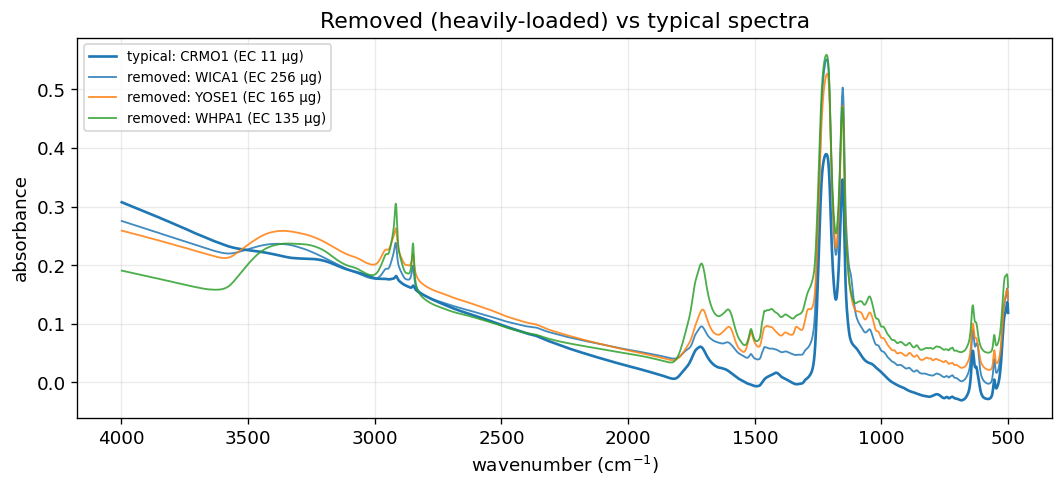

In [6]:
typ=np.argsort(np.abs(y-np.median(y)))[:1][0]   # a near-median (typical) filter
worst=np.where(removed)[0][np.argsort(np.abs(resid_full[removed]))[::-1][:3]]
fig,ax=plt.subplots(figsize=(9,4.2))
ax.plot(wv,X[typ],color="#1f77b4",lw=1.6,label=f"typical: {info.Site[typ]} (EC {y[typ]:.0f} µg)")
for w in worst: ax.plot(wv,X[w],lw=1.1,alpha=.85,label=f"removed: {info.Site[w]} (EC {y[w]:.0f} µg)")
ax.invert_xaxis(); ax.set(xlabel="wavenumber (cm$^{-1}$)",ylabel="absorbance",title="Removed (heavily-loaded) vs typical spectra")
ax.legend(fontsize=8); plt.tight_layout(); plt.savefig(FIG/"fig08_4_spectra.png",bbox_inches="tight"); plt.show()

## Summary (for the slide)
- We start from **all 906** matched IMPROVE EC samples (fig 1).
- A handful sit far off the 1:1 line — flagged by **iterative 3σ** residual trimming (fig 2).
- Removing them (**listed in full** in the table, `tables/ec_removed_filters.csv`) tightens the
  calibration: R² and error improve markedly (fig 3).
- The removed filters are mostly **heavily-loaded** ones whose spectra look clearly different
  (fig 4) — the same filters the tool flags QV ("opaque / heavily loaded").

*Figures: `figures/fig08_1…4_*.png`.*